# ✂️ Notebook 06 — Split Builder for All Ratios

---

<div style="background: linear-gradient(135deg, #0f0c29 0%, #302b63 50%, #24243e 100%); padding: 24px 28px; border-radius: 16px; margin: 12px 0; border: 1px solid #e94560;">
<h2 style="color: #e94560; margin: 0 0 8px 0; font-size: 1.4em;">✂️ Split Builder for All Ratios</h2>
<h3 style="color: #a8dadc; margin: 0 0 16px 0; font-weight: 400; font-size: 1.05em;">Fase A — Fondasi Data dan Eksperimen</h3>
<hr style="border: none; border-top: 1px solid #444; margin: 12px 0;">
<table style="color: #ccc; font-size: 0.9em; border-collapse: collapse; width: 100%;">
<tr><td style="padding: 4px 16px 4px 0; white-space:nowrap;">📍 Studi Kasus</td><td><strong style="color: #fff;">PT. XYZ Banjarmasin, Kalimantan Selatan</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">🎓 Mata Kuliah</td><td><strong style="color: #fff;">Tugas Akhir — ES234733</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">🏛 Institusi</td><td><strong style="color: #fff;">Departemen Sistem Informasi, FTEIC — ITS Surabaya</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">👤 Penulis</td><td><strong style="color: #fff;">Muhammad Iqbal Baiduri Yamani — NRP 5026221103</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">🧑‍🏫 Pembimbing</td><td><strong style="color: #fff;">Edwin Riksakomara, S.Kom., M.T.</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">📅 Tahun</td><td><strong style="color: #fff;">2025</strong></td></tr>
</table>
</div>

## 📌 Tujuan Notebook Ini

Notebook 06 melakukan **pembagian dataset supervised** (`X`, `y`) ke dalam empat rasio *train-test split* yang wajib dievaluasi sesuai Pipeline TA:

| # | Rasio | Train | Test |
|---|-------|-------|------|
| 1 | **60:40** | 213 sampel | 143 sampel |
| 2 | **70:30** | 249 sampel | 107 sampel |
| 3 | **80:20** | 284 sampel | 72 sampel |
| 4 | **90:10** | 320 sampel | 36 sampel |

Notebook ini memastikan setiap split dibentuk **secara kronologis**, sehingga urutan temporal tetap utuh dan tidak terjadi *data leakage* dari data uji ke pipeline pelatihan.

> ⚠️ **Anti-Leakage:** Split dilakukan secara **kronologis**. Tidak ada random shuffle. Data test selalu berada di bagian akhir deret dan tidak pernah menyentuh proses train.

| # | Tahapan | Keterangan |
|---|---------|------------|
| 1 | **Import & Setup** | Muat library, seed, PATHS, dan daftar rasio split |
| 2 | **Load Supervised Dataset** | Load `supervised.npz` → X (356,8), y (356,) |
| 3 | **Build All Splits** | Buat 4 split secara kronologis |
| 4 | **Validasi Integritas Split** | Verifikasi shape, batas indeks, dan konsistensi kronologis |
| 5 | **Visualisasi Split** | Plot distribusi train/test per rasio |
| 6 | **Simpan Artefak** | `.npz` per rasio + ringkasan JSON |
| 7 | **Checklist** | Verifikasi semua item Pipeline.md Gate terpenuhi |

---

### 🔬 Konsep Split Kronologis

**Rumus:**
$$n_{train} = \lfloor n_{samples} \times r_{train} \rfloor, \quad n_{test} = n_{samples} - n_{train}$$

**Sifat penting:**
- $X_{train} = X[:n_{train}]$, $X_{test} = X[n_{train}:]$
- $y_{train} = y[:n_{train}]$, $y_{test} = y[n_{train}:]$
- Tidak ada tumpang tindih indeks antara train dan test
- Urutan temporal terjaga penuh — ini bukan random split

**Alur Proses:**

```mermaid
flowchart LR
    A["💾 supervised.npz\nX (356,8) · y (356,)"] --> B["Buat 4 Rasio Split"]
    B --> C1["60:40\n213 / 143"]
    B --> C2["70:30\n249 / 107"]
    B --> C3["80:20\n284 / 72"]
    B --> C4["90:10\n320 / 36"]
    C1 --> D["Validasi Integritas\nShape · Overlap · Temporal"]
    C2 --> D
    C3 --> D
    C4 --> D
    D --> E["Visualisasi Distribusi"]
    E --> F["💾 splits/split_60_40.npz\n... split_90_10.npz"]
    F --> G["💾 logs/split_summary.json"]
    G --> H["✅ Split Selesai → NB07"]
```

| Aspek | Detail |
|-------|--------|
| **Input** | `supervised.npz` berisi `X` shape (356, 8) dan `y` shape (356,) |
| **Jumlah Rasio** | 4 rasio wajib: **60:40**, **70:30**, **80:20**, **90:10** |
| **Metode Split** | *Chronological split* tanpa shuffle |
| **Validasi** | Shape, jumlah sampel, dan batas train-test diverifikasi |
| **Artefak Output** | `outputs/splits/split_*.npz`, `logs/split_summary.json`, `outputs/figures/nb06_split_overview.png` |

## ⚙️ 1. Import Library & Setup

In [15]:
# ── Import Library & Setup ────────────────────────────────────
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Reproducibility ───────────────────────────────────────────
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

# ── Path Konfigurasi ──────────────────────────────────────────
ROOT_DIR = Path(".").resolve().parent

PATHS = {
    "root"        : ROOT_DIR,
    "data"        : ROOT_DIR / "data",
    "logs"        : ROOT_DIR / "logs",
    "outputs"     : ROOT_DIR / "outputs",
    "figures"     : ROOT_DIR / "outputs" / "figures",
    "models"      : ROOT_DIR / "outputs" / "models",
    "metrics"     : ROOT_DIR / "outputs" / "metrics",
    "splits"      : ROOT_DIR / "outputs" / "splits",
    "cv_folds"    : ROOT_DIR / "outputs" / "cv_folds",
    "checkpoints" : ROOT_DIR / "outputs" / "checkpoints",
    "reports"     : ROOT_DIR / "outputs" / "reports",
    "assets"      : ROOT_DIR / "outputs" / "assets",
    "notebooks"   : ROOT_DIR / "notebook",
}

for p in PATHS.values():
    if isinstance(p, Path):
        p.mkdir(parents=True, exist_ok=True)

# ── Rasio Split yang Wajib Dievaluasi ────────────────────────
SPLIT_RATIOS = [
    ("60:40", 0.60),
    ("70:30", 0.70),
    ("80:20", 0.80),
    ("90:10", 0.90),
]

# ── Matplotlib Style ──────────────────────────────────────────
ACCENT  = "#e94560"
ACCENT2 = "#a8dadc"

plt.rcParams.update({
    "figure.facecolor"  : "#1a1a2e",
    "axes.facecolor"    : "#16213e",
    "axes.edgecolor"    : "#444",
    "axes.labelcolor"   : "#ccc",
    "xtick.color"       : "#aaa",
    "ytick.color"       : "#aaa",
    "text.color"        : "#ddd",
    "grid.color"        : "#2a2a4a",
    "grid.linestyle"    : "--",
    "grid.linewidth"    : 0.5,
    "axes.grid"         : True,
    "font.family"       : "DejaVu Sans",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
})

print("=" * 60)
print("  SETUP — NOTEBOOK 06")
print("=" * 60)
print(f"")
print(f"  GLOBAL_SEED  : {GLOBAL_SEED}")
print(f"  ROOT_DIR     : {ROOT_DIR}")
print(f"  Rasio split  : {[r for r, _ in SPLIT_RATIOS]}")
print(f"  NumPy        : {np.__version__}")
print(f"  Pandas       : {pd.__version__}")
print(f"  Matplotlib   : {matplotlib.__version__}")
print(f"  Seaborn      : {sns.__version__}")
print(f"")
print("  ✅ Setup selesai. Siap Split Builder for All Ratios.")
print("=" * 60)

  SETUP — NOTEBOOK 06

  GLOBAL_SEED  : 42
  ROOT_DIR     : C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting
  Rasio split  : ['60:40', '70:30', '80:20', '90:10']
  NumPy        : 2.4.4
  Pandas       : 3.0.2
  Matplotlib   : 3.10.9
  Seaborn      : 0.13.2

  ✅ Setup selesai. Siap Split Builder for All Ratios.


## 📂 2. Load Supervised Dataset (`supervised.npz`)

In [16]:
# ── Load Supervised Dataset dari NB05 ────────────────────────
npz_path = PATHS["splits"] / "supervised.npz"
assert npz_path.exists(), f"❌ supervised.npz tidak ditemukan: {npz_path}"

data = np.load(npz_path)
X = data["X"]   # (356, 8)
y = data["y"]   # (356,)

n_samples, TAU = X.shape
HORIZON = 1

# ── Muat profile NB05 untuk metadata ─────────────────────────
profile_path = PATHS["logs"] / "sliding_window_profile.json"
with open(profile_path, "r", encoding="utf-8") as f:
    nb05_profile = json.load(f)

print("=" * 60)
print("  LOAD DATA — NOTEBOOK 06")
print("=" * 60)
print(f"")
print(f"  Source       : {npz_path.name}")
print(f"  X shape      : {X.shape}   (n_samples × TAU)")
print(f"  y shape      : {y.shape}   (n_samples,)")
print(f"  TAU          : {TAU}")
print(f"  HORIZON      : {HORIZON}")
print(f"  X dtype      : {X.dtype}")
print(f"  y dtype      : {y.dtype}")
print(f"  y min / max  : {y.min():,.0f} / {y.max():,.0f}")
print(f"  y mean       : {y.mean():,.0f}")
print(f"")
print("  ✅ supervised.npz berhasil dimuat dari artefak NB05.")
print("=" * 60)

  LOAD DATA — NOTEBOOK 06

  Source       : supervised.npz
  X shape      : (356, 8)   (n_samples × TAU)
  y shape      : (356,)   (n_samples,)
  TAU          : 8
  HORIZON      : 1
  X dtype      : float64
  y dtype      : float64
  y min / max  : 2,527 / 102,666
  y mean       : 53,274

  ✅ supervised.npz berhasil dimuat dari artefak NB05.


## ✂️ 3. Split Builder (Semua Rasio)

In [17]:
# ── Build All Splits (temporal / kronologis) ──────────────────
def build_split(X, y, train_ratio, label):
    """
    Kronologis train-test split tanpa shuffle.
    Train = sampel pertama, Test = sampel terakhir.
    """
    n = len(y)
    n_train = int(np.floor(n * train_ratio))
    n_test  = n - n_train

    X_train, y_train = X[:n_train], y[:n_train]
    X_test,  y_test  = X[n_train:], y[n_train:]

    # Anti-leakage check
    assert n_train + n_test == n, "Total sampel tidak konsisten!"
    assert len(np.intersect1d(
        np.arange(n_train), np.arange(n_train, n)
    )) == 0, "Indeks train dan test tumpang tindih!"

    return {
        "label"        : label,
        "train_ratio"  : train_ratio,
        "n_total"      : n,
        "n_train"      : n_train,
        "n_test"       : n_test,
        "X_train"      : X_train,
        "y_train"      : y_train,
        "X_test"       : X_test,
        "y_test"       : y_test,
    }

# ── Bangun semua 4 split ───────────────────────────────────────
splits = {}
for label, ratio in SPLIT_RATIOS:
    sp = build_split(X, y, ratio, label)
    splits[label] = sp

# ── Print ringkasan ────────────────────────────────────────────
print("=" * 70)
print("  SPLIT BUILDER — RINGKASAN SEMUA RASIO")
print("=" * 70)
print(f"  {'Rasio':<10} {'N_Total':>8} {'N_Train':>9} {'N_Test':>8} "
      f"{'X_train':>14} {'X_test':>13}")
print("  " + "-" * 66)
for label, sp in splits.items():
    print(f"  {sp['label']:<10} {sp['n_total']:>8} {sp['n_train']:>9} "
          f"{sp['n_test']:>8} "
          f"  {str(sp['X_train'].shape):>12}  {str(sp['X_test'].shape):>12}")
print("=" * 70)
print(f"")
print(f"  ✅ Semua 4 split berhasil dibangun secara kronologis.")
print(f"  ✅ Tidak ada data leakage antar train dan test set.")
print("=" * 70)

  SPLIT BUILDER — RINGKASAN SEMUA RASIO
  Rasio       N_Total   N_Train   N_Test        X_train        X_test
  ------------------------------------------------------------------
  60:40           356       213      143       (213, 8)      (143, 8)
  70:30           356       249      107       (249, 8)      (107, 8)
  80:20           356       284       72       (284, 8)       (72, 8)
  90:10           356       320       36       (320, 8)       (36, 8)

  ✅ Semua 4 split berhasil dibangun secara kronologis.
  ✅ Tidak ada data leakage antar train dan test set.


## 🔍 4. Validasi Integritas & Visualisasi Split

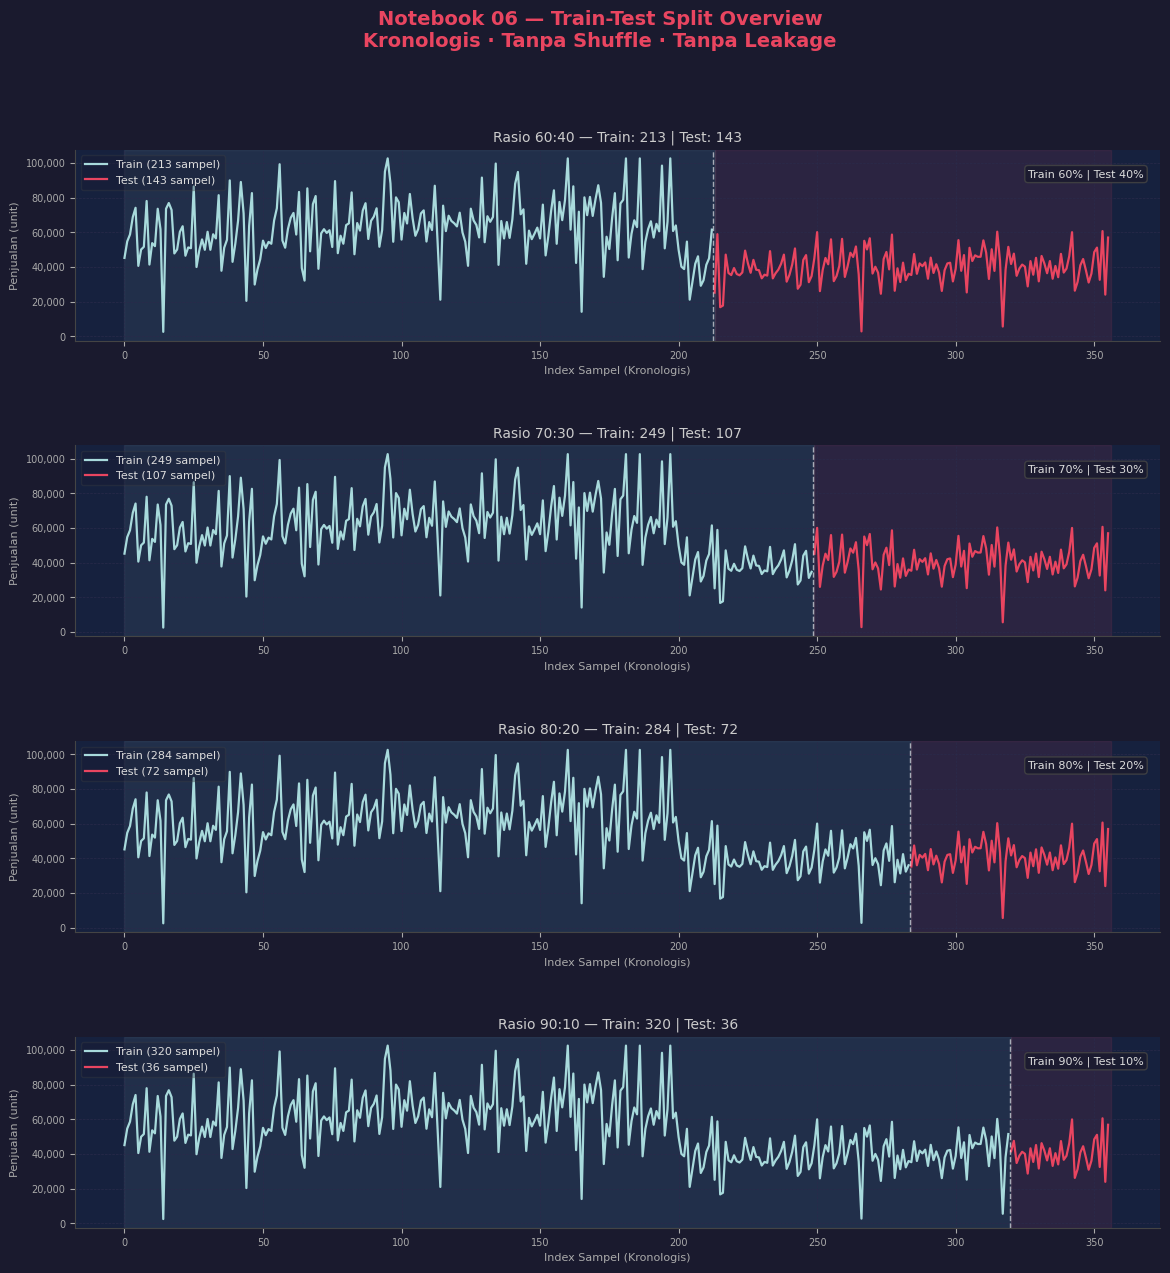

  VALIDASI INTEGRITAS & VISUALISASI — NOTEBOOK 06
  ✅ 60:40 shape_ok       : True
  ✅ 60:40 chronology_ok  : True
  ✅ 60:40 boundary_ok    : True
  ✅ 70:30 shape_ok       : True
  ✅ 70:30 chronology_ok  : True
  ✅ 70:30 boundary_ok    : True
  ✅ 80:20 shape_ok       : True
  ✅ 80:20 chronology_ok  : True
  ✅ 80:20 boundary_ok    : True
  ✅ 90:10 shape_ok       : True
  ✅ 90:10 chronology_ok  : True
  ✅ 90:10 boundary_ok    : True
  ✅ Figur tersimpan    : nb06_split_overview.png
  ✅ Semua validasi     : True


In [18]:
# ── Validasi Integritas & Visualisasi Split Overview ───────────
validation_rows = []

for label, sp in splits.items():
    n_tr = sp["n_train"]
    n_te = sp["n_test"]

    validation_rows.append({
        "label": label,
        "shape_ok": (
            sp["X_train"].shape == (n_tr, TAU)
            and sp["X_test"].shape == (n_te, TAU)
            and sp["y_train"].shape == (n_tr,)
            and sp["y_test"].shape == (n_te,)
        ),
        "chronology_ok": (
            n_tr > 0
            and n_te > 0
            and len(sp["y_train"]) + len(sp["y_test"]) == n_samples
        ),
        "boundary_ok": (
            np.allclose(sp["X_train"][-1], X[n_tr - 1])
            and np.isclose(sp["y_train"][-1], y[n_tr - 1])
            and np.allclose(sp["X_test"][0], X[n_tr])
            and np.isclose(sp["y_test"][0], y[n_tr])
        ),
    })

fig, axes = plt.subplots(
    4, 1, figsize=(14, 14), facecolor="#1a1a2e",
    gridspec_kw={"hspace": 0.55}
    )

fig.suptitle(
    "Notebook 06 — Train-Test Split Overview\nKronologis · Tanpa Shuffle · Tanpa Leakage",
    color="#e94560", fontsize=14, fontweight="bold", y=0.98
)

x_idx = np.arange(n_samples)

for ax, (label, sp) in zip(axes, splits.items()):
    n_tr = sp["n_train"]
    n_te = sp["n_test"]
    ratio_train = int(round((n_tr / n_samples) * 100))
    ratio_test = 100 - ratio_train

    ax.set_facecolor("#16213e")
    ax.plot(
        x_idx[:n_tr], sp["y_train"], color=ACCENT2, lw=1.6,
        label=f"Train ({n_tr} sampel)"
    )
    ax.plot(
        x_idx[n_tr:], sp["y_test"], color=ACCENT, lw=1.6,
        label=f"Test ({n_te} sampel)"
    )

    ax.axvline(x=n_tr - 0.5, color="#fff", lw=1.0, ls="--", alpha=0.6)
    ax.axvspan(0, n_tr, alpha=0.08, color=ACCENT2)
    ax.axvspan(n_tr, n_samples, alpha=0.10, color=ACCENT)

    ax.set_title(
        f"Rasio {label} — Train: {n_tr} | Test: {n_te}",
        color="#ccc", fontsize=10, pad=6
    )
    ax.set_xlabel("Index Sampel (Kronologis)", color="#aaa", fontsize=8)
    ax.set_ylabel("Penjualan (unit)", color="#aaa", fontsize=8)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda val, _: f"{val:,.0f}")
    )
    ax.legend(
        loc="upper left", framealpha=0.3, fontsize=8,
        labelcolor="#ddd", facecolor="#1a1a2e", edgecolor="#444"
    )
    ax.tick_params(labelsize=7)
    ax.text(
        0.985, 0.90,
        f"Train {ratio_train}% | Test {ratio_test}%",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=8, color="#ddd",
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "#1a1a2e", "edgecolor": "#444", "alpha": 0.85}
    )

    for spine in ax.spines.values():
        spine.set_color("#444")

plt.tight_layout(rect=[0, 0, 1, 0.97])

out_path = PATHS["figures"] / "nb06_split_overview.png"
fig.savefig(
    out_path, dpi=150, bbox_inches="tight",
    facecolor=fig.get_facecolor()
    )
plt.show()

all_validation_pass = all(
    row["shape_ok"] and row["chronology_ok"] and row["boundary_ok"]
    for row in validation_rows
    )

print("=" * 60)
print("  VALIDASI INTEGRITAS & VISUALISASI — NOTEBOOK 06")
print("=" * 60)
for row in validation_rows:
    print(f"  ✅ {row['label']} shape_ok       : {row['shape_ok']}")
    print(f"  ✅ {row['label']} chronology_ok  : {row['chronology_ok']}")
    print(f"  ✅ {row['label']} boundary_ok    : {row['boundary_ok']}")
print(f"  ✅ Figur tersimpan    : {out_path.name}")
print(f"  ✅ Semua validasi     : {all_validation_pass}")
print("=" * 60)

## 💾 5. Simpan Artefak

In [19]:
# ── Simpan setiap split sebagai .npz ──────────────────────────
LABEL_TO_FILENAME = {
    "60:40": "split_60_40",
    "70:30": "split_70_30",
    "80:20": "split_80_20",
    "90:10": "split_90_10",
}

split_summary = {}

print("=" * 60)
print("  SIMPAN ARTEFAK — NOTEBOOK 06")
print("=" * 60)

for label, sp in splits.items():
    fname = LABEL_TO_FILENAME[label]
    out_npz = PATHS["splits"] / f"{fname}.npz"

    np.savez_compressed(
        out_npz,
        X_train = sp["X_train"],
        y_train = sp["y_train"],
        X_test  = sp["X_test"],
        y_test  = sp["y_test"],
    )

    # ── Round-trip verify ─────────────────────────────────────
    rt = np.load(out_npz)
    assert rt["X_train"].shape == sp["X_train"].shape
    assert rt["y_train"].shape == sp["y_train"].shape
    assert rt["X_test"].shape  == sp["X_test"].shape
    assert rt["y_test"].shape  == sp["y_test"].shape
    assert np.allclose(rt["y_train"], sp["y_train"])
    assert np.allclose(rt["y_test"],  sp["y_test"])

    split_summary[label] = {
        "file"         : f"{fname}.npz",
        "train_ratio"  : sp["train_ratio"],
        "n_total"      : int(sp["n_total"]),
        "n_train"      : int(sp["n_train"]),
        "n_test"       : int(sp["n_test"]),
        "X_train_shape": list(sp["X_train"].shape),
        "y_train_shape": list(sp["y_train"].shape),
        "X_test_shape" : list(sp["X_test"].shape),
        "y_test_shape" : list(sp["y_test"].shape),
        "y_train_mean" : float(sp["y_train"].mean()),
        "y_train_std"  : float(sp["y_train"].std()),
        "y_test_mean"  : float(sp["y_test"].mean()),
        "y_test_std"   : float(sp["y_test"].std()),
    }

    print(f"  ✅ {fname}.npz → X_train{sp['X_train'].shape} "
          f"y_train{sp['y_train'].shape} | "
          f"X_test{sp['X_test'].shape} y_test{sp['y_test'].shape}")

# ── Simpan split_summary.json ──────────────────────────────────
json_path = PATHS["logs"] / "split_summary.json"

summary_payload = {
    "notebook"          : "06 - Split Builder for All Ratios",
    "source_file"       : "supervised.npz",
    "n_samples_total"   : n_samples,
    "TAU"               : TAU,
    "HORIZON"           : HORIZON,
    "global_seed"       : GLOBAL_SEED,
    "splits"            : split_summary,
    "figure"            : "nb06_split_overview.png",
}

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(summary_payload, f, indent=2, ensure_ascii=False)

# Round-trip verify JSON
with open(json_path, "r", encoding="utf-8") as f:
    rt_json = json.load(f)

assert len(rt_json["splits"]) == len(splits), "Jumlah split tidak sesuai!"
for label in splits:
    assert label in rt_json["splits"], f"Rasio {label} tidak ada di JSON!"

print(f"")
print(f"  ✅ split_summary.json → {json_path}")
print(f"  ✅ Round-trip JSON OK — {len(rt_json['splits'])} rasio tersimpan.")
print("=" * 60)

  SIMPAN ARTEFAK — NOTEBOOK 06
  ✅ split_60_40.npz → X_train(213, 8) y_train(213,) | X_test(143, 8) y_test(143,)
  ✅ split_70_30.npz → X_train(249, 8) y_train(249,) | X_test(107, 8) y_test(107,)
  ✅ split_80_20.npz → X_train(284, 8) y_train(284,) | X_test(72, 8) y_test(72,)
  ✅ split_90_10.npz → X_train(320, 8) y_train(320,) | X_test(36, 8) y_test(36,)

  ✅ split_summary.json → C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting\logs\split_summary.json
  ✅ Round-trip JSON OK — 4 rasio tersimpan.


## ✅ 6. Checklist

In [ ]:
# ── Checklist Akhir Notebook 06 ──────────────────────────────
sp6040 = splits["60:40"]
sp7030 = splits["70:30"]
sp8020 = splits["80:20"]
sp9010 = splits["90:10"]

split_60_exists = (PATHS["splits"] / "split_60_40.npz").exists()
split_70_exists = (PATHS["splits"] / "split_70_30.npz").exists()
split_80_exists = (PATHS["splits"] / "split_80_20.npz").exists()
split_90_exists = (PATHS["splits"] / "split_90_10.npz").exists()
summary_exists  = (PATHS["logs"] / "split_summary.json").exists()
figure_exists   = (PATHS["figures"] / "nb06_split_overview.png").exists()

split_60_ok = (
    sp6040["n_train"] == int(np.floor(n_samples * 0.60))
    and sp6040["n_test"] == n_samples - sp6040["n_train"]
    and sp6040["X_train"].shape == (sp6040["n_train"], TAU)
    and sp6040["X_test"].shape == (sp6040["n_test"], TAU)
    and split_60_exists
)

split_70_ok = (
    sp7030["n_train"] == int(np.floor(n_samples * 0.70))
    and sp7030["n_test"] == n_samples - sp7030["n_train"]
    and sp7030["X_train"].shape == (sp7030["n_train"], TAU)
    and sp7030["X_test"].shape == (sp7030["n_test"], TAU)
    and split_70_exists
)

split_80_ok = (
    sp8020["n_train"] == int(np.floor(n_samples * 0.80))
    and sp8020["n_test"] == n_samples - sp8020["n_train"]
    and sp8020["X_train"].shape == (sp8020["n_train"], TAU)
    and sp8020["X_test"].shape == (sp8020["n_test"], TAU)
    and split_80_exists
)

split_90_ok = (
    sp9010["n_train"] == int(np.floor(n_samples * 0.90))
    and sp9010["n_test"] == n_samples - sp9010["n_train"]
    and sp9010["X_train"].shape == (sp9010["n_train"], TAU)
    and sp9010["X_test"].shape == (sp9010["n_test"], TAU)
    and split_90_exists
)

summary_ok = (
    summary_exists
    and figure_exists
    and len(rt_json["splits"]) == 4
)

checklist = [
    ("Split 60:40 selesai",                    split_60_ok),
    ("Split 70:30 selesai",                    split_70_ok),
    ("Split 80:20 selesai",                    split_80_ok),
    ("Split 90:10 selesai",                    split_90_ok),
    ("split_summary.json dan figur tersimpan", summary_ok),
]

print("=" * 60)
print("  CHECKLIST NOTEBOOK 06")
print("=" * 60)
all_pass = True
for label, status in checklist:
    icon = "✅" if status else "❌"
    if not status:
        all_pass = False
    print(f"  {icon}  {label}")
print("=" * 60)
if all_pass:
    print("  ✅ SEMUA CHECKLIST LULUS — Notebook 06 selesai!")
    print("     Lanjutkan ke Notebook 07 — Walk-Forward CV Builder.")
else:
    print("  ❌ Ada checklist yang GAGAL — periksa log di atas.")
print("=" * 60)

  CHECKLIST NOTEBOOK 06
  ✅  Split 60:40 selesai
  ✅  Split 70:30 selesai
  ✅  Split 80:20 selesai
  ✅  Split 90:10 selesai
  ✅  split_summary.json dan figur tersimpan
  ✅ SEMUA CHECKLIST LULUS — Notebook 06 selesai!
     Lanjutkan ke Notebook 07 — Walk-Forward CV Builder.


---

## 🔗 Navigasi Pipeline

| | Notebook |
|--|----------|
| ← | **[05 - Sliding Window Supervised Framing](./05%20-%20Sliding%20Window%20Supervised%20Framing.ipynb)** |
| **→** | **[07 - Walk-Forward CV Builder](./07%20-%20Walk-Forward%20CV%20Builder.ipynb)** |

---

### 📎 Variabel Penting yang Dihasilkan Notebook Ini

Variabel berikut tersedia untuk notebook selanjutnya (dimuat ulang dari file atau dihitung kembali):

```python
X                    # np.ndarray, shape (356, 8), float64 — supervised features
y                    # np.ndarray, shape (356,), float64   — supervised targets
splits               # dict — seluruh train-test split kronologis
split_summary        # dict — ringkasan metadata semua rasio
PATHS                # dict path pipeline (sama seperti notebook sebelumnya)

# Artefak tersimpan:
# outputs/splits/split_60_40.npz
# outputs/splits/split_70_30.npz
# outputs/splits/split_80_20.npz
# outputs/splits/split_90_10.npz
# logs/split_summary.json
# outputs/figures/nb06_split_overview.png
```

---

<div style="text-align: center; color: #888; font-size: 0.85em; padding: 12px 0;">
Notebook 06 — Split Builder for All Ratios &nbsp;|&nbsp;
CNN–BiLSTM + GA Sales Forecasting &nbsp;|&nbsp;
Departemen Sistem Informasi ITS Surabaya &nbsp;|&nbsp; 2025
</div>